In [ ]:
import numpy as np
import os

def generate_2d_riemann_mesh(
    nx=512,
    ny=512,
    gamma=1.4,
    output_dir="mesh"
):
    os.makedirs(output_dir, exist_ok=True)

    # 计算域 [0,1]x[0,1]
    domain_size = 1
    da = domain_size / nx

    rho    = np.zeros((ny, nx))
    u      = np.zeros((ny, nx))
    v      = np.zeros((ny, nx))
    p      = np.zeros((ny, nx))
    bctype = np.zeros((ny, nx), dtype=np.int32)

    # 界面位置（列/行索引）
    # i=0 对应 y=1（顶部），i 增大 y 减小
    # j=0 对应 x=0（左侧），j 增大 x 增大
    x_int = 0.85   # x 界面
    y_int = 0.85   # y 界面

    for i in range(ny):
        for j in range(nx):
            # 单元中心坐标
            xc = (j + 0.5) * da          # x ∈ [0,1]
            yc = 1.0 - (i + 0.5) * da   # y ∈ [0,1]，i=0→顶部

            if xc >= x_int and yc >= y_int:
                # 右上象限：ρ=1.5, u=0, v=0, p=1.5
                rho[i,j], u[i,j], v[i,j], p[i,j] = 1.5, 0.0, 0.0, 1.5

            elif xc < x_int and yc >= y_int:
                # 左上象限：ρ=0.5323, u=1.206, v=0, p=0.3
                rho[i,j], u[i,j], v[i,j], p[i,j] = 0.5323, 1.206, 0.0, 0.3

            elif xc < x_int and yc < y_int:
                # 左下象限：ρ=0.138, u=1.206, v=-1.206, p=0.029
                rho[i,j], u[i,j], v[i,j], p[i,j] = 0.138, 1.206, -1.206, 0.029

            else:
                # 右下象限：ρ=0.5323, u=0, v=-1.206, p=0.3
                rho[i,j], u[i,j], v[i,j], p[i,j] = 0.5323, 0.0, -1.206, 0.3

            # 边界类型：最外两圈为 -1（固壁/零梯度）
            if i < 3 or i >= ny-3 or j < 3 or j >= nx-3:
                bctype[i,j] = -1
            else:
                bctype[i,j] = 0

    # 保存 params.txt
    with open(os.path.join(output_dir, "params.txt"), "w") as f:
        f.write(f"{nx} {ny} {da:.10e} {gamma}\n")

    # 保存矩阵（Eigen 行优先文本格式）
    def save_matrix(filename, data, is_int=False):
        with open(os.path.join(output_dir, filename), "w") as f:
            for i in range(data.shape[0]):
                for j in range(data.shape[1]):
                    if is_int:
                        f.write(f"{int(data[i,j])} ")
                    else:
                        f.write(f"{data[i,j]:.10e} ")
                f.write("\n")

    save_matrix("rho.dat",    rho)
    save_matrix("u.dat",      u)
    save_matrix("v.dat",      v)
    save_matrix("p.dat",      p)
    save_matrix("bctype.dat", bctype, is_int=True)

    print("========== 四象限初始条件 ==========")
    print(f"右上 (x≥0.85, y≥0.85): ρ=1.5,    u=0,     v=0,      p=1.5")
    print(f"左上 (x<0.85, y≥0.85): ρ=0.5323, u=1.206, v=0,      p=0.3")
    print(f"左下 (x<0.85, y<0.85): ρ=0.138,  u=1.206, v=-1.206, p=0.029")
    print(f"右下 (x≥0.85, y<0.85): ρ=0.5323, u=0,     v=-1.206, p=0.3")
    print(f"\n网格: {ny}×{nx}, da={da:.6f}, 输出: {os.path.abspath(output_dir)}")

if __name__ == "__main__":
    generate_2d_riemann_mesh(nx=512, ny=512, gamma=1.4, output_dir="mesh")

========== 四象限初始条件 ==========
右上 (x≥0.9, y≥0.9): ρ=1.5,    u=0,     v=0,      p=1.5
左上 (x<0.9, y≥0.9): ρ=0.5323, u=1.206, v=0,      p=0.3
左下 (x<0.9, y<0.9): ρ=0.138,  u=1.206, v=-1.206, p=0.029
右下 (x≥0.9, y<0.9): ρ=0.5323, u=0,     v=-1.206, p=0.3

网格: 128×128, da=0.007812, 输出: /home/midway/ZuikakuCFD/mesh


   核爆模拟初始化 (SI单位)
-------------------------------------------------------
  计算域大小   : 2000.0m x 2000.0m
  网格分辨率   : 1024 x 1024
  网格间距 da  : 1.9531 m
  核心半径 R0  : 15.0 m
  环境声速     : 340.29 m/s
  激波初速度   : 98.97 km/s (Mach 290.85)


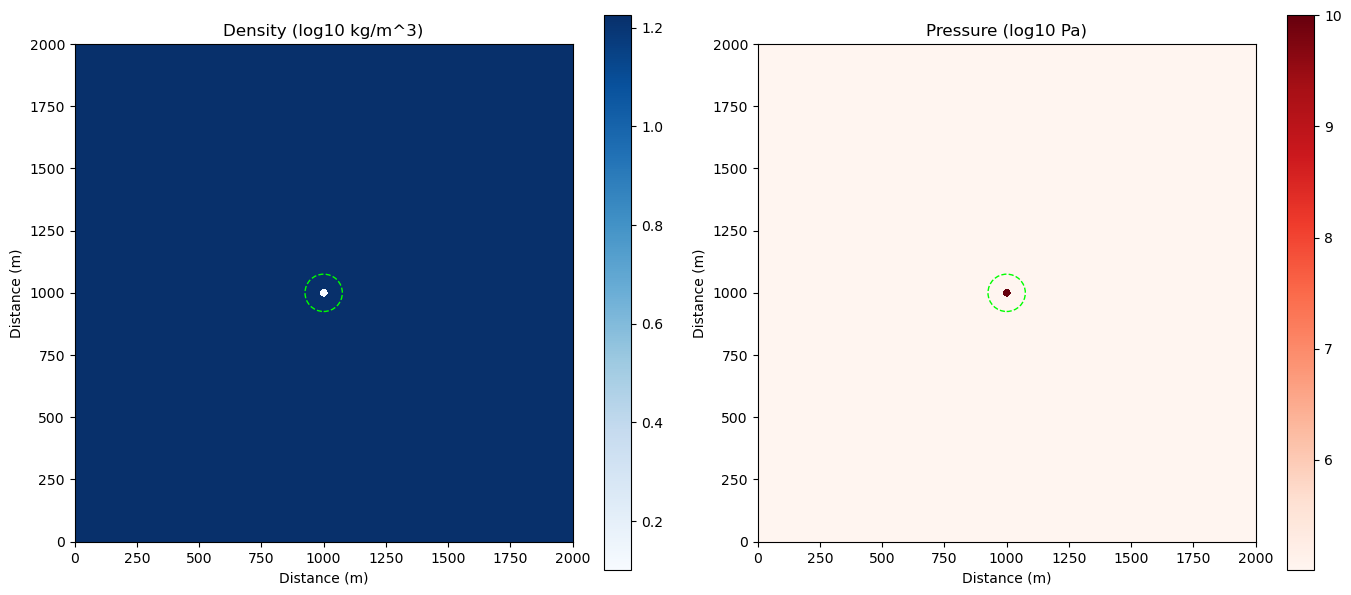

In [38]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_center_detonation_mesh_si(
    nx=512,
    ny=512,
    gamma=1.4,
    domain_size=2000.0, # 总区域大小：2000米
    R0=10.0,            # 爆轰核心半径：10米
    # ---- 核心区（SI单位） ----
    rho_in=0.1,         # 高温等离子体密度 (kg/m^3)
    p_in=1e10,          # 核心压强 (Pa)
    # ---- 外部区（SI单位） ----
    rho_out=1.225,      # 标准空气密度 (kg/m^3)
    p_out=101325.0,     # 标准大气压 (Pa)
    output_dir="./mesh_nuclear_si"
):
    os.makedirs(output_dir, exist_ok=True)

    # 1. 计算格点间距 (m)
    da = domain_size / nx 

    rho    = np.zeros((ny, nx))
    u      = np.zeros((ny, nx))
    v      = np.zeros((ny, nx))
    p      = np.zeros((ny, nx))
    bctype = np.zeros((ny, nx), dtype=np.int32)

    # 2. 爆轰中心坐标 (m)
    cx, cy = domain_size / 2.0, domain_size / 2.0  

    # 3. 坐标向量化生成
    jj = np.arange(nx)
    ii = np.arange(ny)
    # 物理坐标：从 0 到 2000m
    xc = (jj + 0.5) * da 
    yc = domain_size - (ii + 0.5) * da 

    XC, YC = np.meshgrid(xc, yc)
    r2 = (XC - cx)**2 + (YC - cy)**2

    inside = r2 <= R0**2

    # 初始化流场
    rho[:] = rho_out
    u[:]   = 0.0
    v[:]   = 0.0
    p[:]   = p_out

    rho[inside] = rho_in
    p[inside]   = p_in

    # 边界条件：-1 通常代表透射边界（Outflow）
    bctype[:2,  :]  = -1
    bctype[-2:, :]  = -1
    bctype[:,  :2]  = -1
    bctype[:, -2:]  = -1

    # 保存参数
    with open(os.path.join(output_dir, "params.txt"), "w") as f:
        f.write(f"{nx} {ny} {da:.10e} {gamma}\n")

    # 保存矩阵（Eigen 行优先文本格式）
    def save_matrix(filename, data, is_int=False):
        with open(os.path.join(output_dir, filename), "w") as f:
            for i in range(data.shape[0]):
                for j in range(data.shape[1]):
                    if is_int:
                        f.write(f"{int(data[i,j])} ")
                    else:
                        f.write(f"{data[i,j]:.10e} ")
                f.write("\n")

    save_matrix("rho.dat", rho)
    save_matrix("u.dat", u)
    save_matrix("v.dat", v)
    save_matrix("p.dat", p)
    save_matrix("bctype.dat", bctype, is_int=True)

    # 物理量计算与输出 (SI)
    eta = p_in / p_out
    c_out = np.sqrt(gamma * p_out / rho_out)
    M = np.sqrt(((gamma + 1) * eta + (gamma - 1)) / (2 * gamma))
    Vs = M * c_out

    print("=" * 55)
    print(f"   核爆模拟初始化 (SI单位)")
    print("-" * 55)
    print(f"  计算域大小   : {domain_size}m x {domain_size}m")
    print(f"  网格分辨率   : {nx} x {ny}")
    print(f"  网格间距 da  : {da:.4f} m")
    print(f"  核心半径 R0  : {R0} m")
    print(f"  环境声速     : {c_out:.2f} m/s")
    print(f"  激波初速度   : {Vs/1000:.2f} km/s (Mach {M:.2f})")
    print("=" * 55)

    _plot_initial_condition_si(rho, p, XC, YC, R0, cx, cy, output_dir)
    return rho, u, v, p, bctype

def _plot_initial_condition_si(rho, p, XC, YC, R0, cx, cy, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 使用对数坐标绘图，否则压强差太大看不清环境区
    fields = [(rho, "Density (log10 kg/m^3)", "Blues"), (np.log10(p), "Pressure (log10 Pa)", "Reds")]
    
    for ax, (field, title, cmap) in zip(axes, fields):
        im = ax.pcolormesh(XC, YC, field, cmap=cmap, shading='auto')
        plt.colorbar(im, ax=ax)
        circle = patches.Circle((cx, cy), R0*5, linewidth=1, # 放大5倍画圈方便肉眼观察
                                 edgecolor='lime', facecolor='none', linestyle='--', label=f'R0={R0}m')
        ax.add_patch(circle)
        ax.set_title(title)
        ax.set_xlabel("Distance (m)")
        ax.set_ylabel("Distance (m)")
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "initial_si.png"))
    plt.show()

if __name__ == "__main__":
    generate_center_detonation_mesh_si(
        nx=1024, 
        ny=1024, 
        domain_size=2000.0, 
        R0=15.0, 
        p_in=1e10  # 约 10 万个大气压，模拟强冲击波
    )